In [1]:
import logging
from dotenv import load_dotenv
from evals import Dataset
from evals.metrics import CollectMetrics
import warnings
from huggingface_hub.utils import _http
logger = logging.getLogger(__name__)

logging.getLogger(__name__).setLevel(logging.DEBUG)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)

warnings.filterwarnings(
    "ignore",
    message=".*UNEXPECTED.*",          # matcher alle linjer med UNEXPECTED
    category=UserWarning,
    module="transformers.modeling_utils"  # eller bare "transformers" hvis det ikke funker
)

load_dotenv()

True

## Fetch results

In [2]:
ds = Dataset("test")
cm = CollectMetrics()
eval_res = ds.load_evaluation_results()
all_eval_runs = cm.organize_runs_by_type(eval_res)

In [3]:
coll_res = ds.load_results()
all_collected_res = cm.organize_runs_by_type(coll_res)

In [4]:
deepeval_obs = []
for runs in all_eval_runs.values():
    deepeval_obs.extend(cm.collect_deepeval_metrics(runs))

deepeval_obs[:2], len(deepeval_obs)

([DeepEvalObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name='Turn unknown in session Prosjekt-initialisering', correctness=0.7, relevancy=0.7, completeness=0.9, success=True),
  DeepEvalObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name='Turn 1 in session Prosjekt-initialisering', correctness=0.8, relevancy=1.0, completeness=0.7, success=True)],
 44)

In [5]:
berts = []
for runs in all_eval_runs.values():
    berts.extend(cm.collect_berts(runs))

berts[:2], len(berts)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

([ReferenceObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name=None, bert_precision=0.5848439335823059, bert_recall=0.690008819103241, bert_f1=0.6330887675285339, s_bert_similarity=0.9543586059131249),
  ReferenceObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name=None, bert_precision=0.6300543546676636, bert_recall=0.7086403965950012, bert_f1=0.6670407056808472, s_bert_similarity=0.9181707722712509)],
 44)

In [6]:
gathered_res = ds.load_results()
resource_obs = cm.collect_resource_metrics(list(gathered_res.values()))

resource_obs[:2], len(resource_obs)

([ResourceObservation(starttime=datetime.datetime(2026, 3, 7, 18, 47, 34, 992180), endtime=datetime.datetime(2026, 3, 7, 18, 47, 45, 760740), duration_seconds=10.76856, input_tokens=9943, output_tokens=1566, total_tokens=11509, llm_calls=1, dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom'),
  ResourceObservation(starttime=datetime.datetime(2026, 3, 7, 18, 47, 45, 760950), endtime=datetime.datetime(2026, 3, 7, 18, 48, 5, 684568), duration_seconds=19.923618, input_tokens=27706, output_tokens=2993, total_tokens=30699, llm_calls=2, dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model=

## EDA
### Exploratory data analysis

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import subplots
import pandas as pd

In [8]:
df_de = pd.DataFrame([dp.model_dump() for dp in deepeval_obs])
df_brt = pd.DataFrame([bert.model_dump() for bert in berts])
df_rm = pd.DataFrame([rm.model_dump() for rm in resource_obs])
drop = ["eval_run_id", 
        "name",
        #"query_id", "session_id", 
        ]
on = ["llm_model", "dataset_name", 
        "query_id", "session_id", "agent_type",
        "session", "session_name"]

df = pd.merge(df_de.drop(columns=drop, errors = "ignore"), df_rm.drop(columns=drop, errors = "ignore"), on = on,)
                                                                                                              
df = pd.merge(df, df_brt.drop(columns=drop, errors = "ignore"), on = on)

In [10]:
df.head()

,dataset_name,query_id,session_id,session,session_name,llm_model,agent_type,correctness,relevancy,completeness,...,endtime,duration_seconds,input_tokens,output_tokens,total_tokens,llm_calls,bert_precision,bert_recall,bert_f1,s_bert_similarity
0,test,f3f226bb-eb5c-4b87-8d96-dfa425614f42,0b784eaf-8d41-4990-84c9-1d50f34de5fa,0,Prosjekt-initialisering,google_gemini-2.5-flash,custom,0.7,0.7,0.9,...,2026-03-07 18:47:45.760740,10.768560,9943,1566,11509,1,0.584844,0.690009,0.633089,0.954359
1,test,070f570b-f9d0-454f-90ca-84f66ede1a31,0b784eaf-8d41-4990-84c9-1d50f34de5fa,0,Prosjekt-initialisering,google_gemini-2.5-flash,custom,0.8,1.0,0.7,...,2026-03-07 18:48:05.684568,19.923618,27706,2993,30699,2,0.630054,0.708640,0.667041,0.918171
2,test,e17e38f3-0c98-4fbf-bb93-a30742d8efc2,9c4e5a04-8c02-4e1f-b178-02b3e46e8ecd,1,Stevning og tilsvar,google_gemini-2.5-flash,custom,0.5,0.4,0.4,...,2026-03-07 18:50:54.397872,5.384846,17284,807,18091,1,0.619952,0.675889,0.646713,0.880004
3,test,c064ef16-3081-44f8-8444-b0df672ec840,9c4e5a04-8c02-4e1f-b178-02b3e46e8ecd,1,Stevning og tilsvar,google_gemini-2.5-flash,custom,0.6,1.0,0.8,...,2026-03-07 18:50:49.012785,13.205039,30683,1813,32496,2,0.686709,0.724534,0.705115,0.922206
4,test,f3f226bb-eb5c-4b87-8d96-dfa425614f42,4cdeb92e-0849-42e8-bed3-44b4ae13e36a,0,Prosjekt-initialisering,google_gemini-2.5-flash,custom,1.0,0.8,1.0,...,2026-03-07 17:37:15.205409,9.038186,9439,1158,10597,1,0.638840,0.679709,0.658641,0.946664


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dataset_name       44 non-null     object        
 1   query_id           44 non-null     object        
 2   session_id         44 non-null     object        
 3   session            0 non-null      object        
 4   session_name       0 non-null      object        
 5   llm_model          44 non-null     object        
 6   agent_type         44 non-null     object        
 7   correctness        44 non-null     float64       
 8   relevancy          44 non-null     float64       
 9   completeness       44 non-null     float64       
 10  success            44 non-null     bool          
 11  starttime          44 non-null     datetime64[ns]
 12  endtime            44 non-null     datetime64[ns]
 13  duration_seconds   44 non-null     float64       
 14  input_tokens

In [11]:
df.loc[df["llm_model"] == "qwen_Qwen/Qwen3-Next-80B-A3B-Instruct" , "llm_model"] = "Qwen3-Next-80B-A3B-Instruct"
df.loc[df["llm_model"] == "qwen_Qwen/Qwen3.5-397B-A17B" , "llm_model"] = "Qwen3.5-397B-A17B"

df["llm_model"].value_counts()

llm_model
Qwen3-Next-80B-A3B-Instruct    24
Qwen3.5-397B-A17B              12
google_gemini-2.5-flash         8
Name: count, dtype: int64

### Deep Eval metrics
Correctness, relevancy & completeness

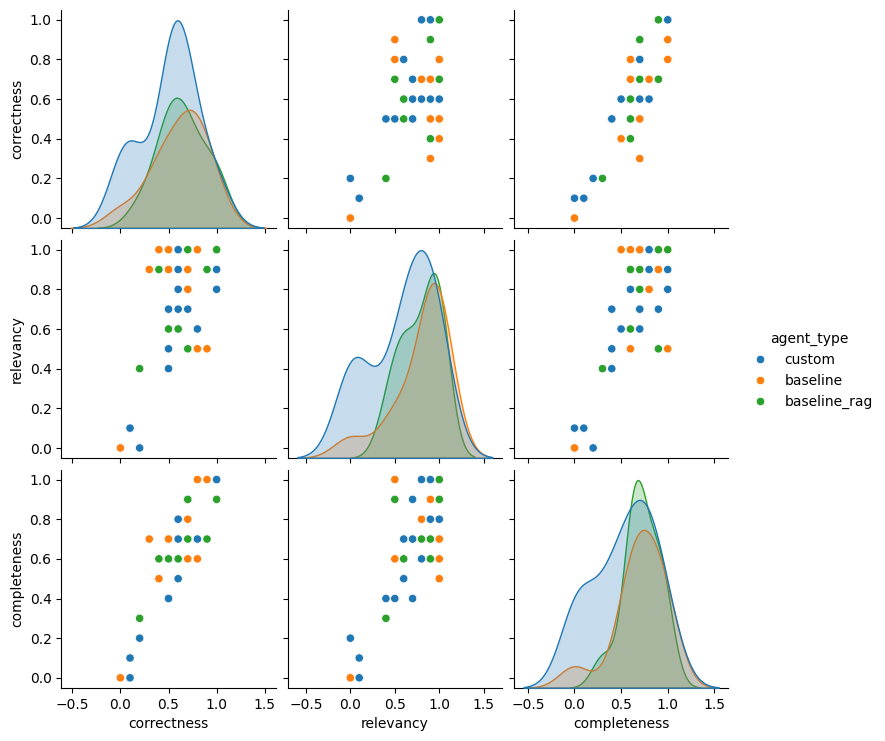

In [12]:
sns.pairplot(df[["correctness", "relevancy", "completeness", "llm_model", "agent_type"]], hue = "agent_type")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dataset_name       44 non-null     object        
 1   query_id           44 non-null     object        
 2   session_id         44 non-null     object        
 3   session            44 non-null     int64         
 4   session_name       44 non-null     object        
 5   llm_model          44 non-null     object        
 6   agent_type         44 non-null     object        
 7   correctness        44 non-null     float64       
 8   relevancy          44 non-null     float64       
 9   completeness       44 non-null     float64       
 10  success            44 non-null     bool          
 11  starttime          44 non-null     datetime64[ns]
 12  endtime            44 non-null     datetime64[ns]
 13  duration_seconds   44 non-null     float64       
 14  input_tokens

<Axes: xlabel='success', ylabel='Count'>

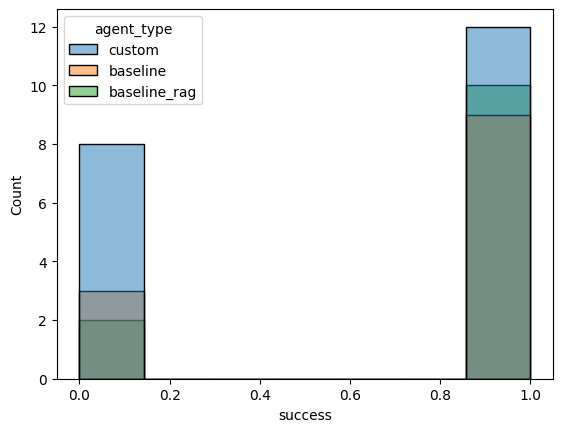

In [14]:
sns.histplot(df, x = "success", hue = "agent_type")

### Bert metrics
S-bert & Bert score

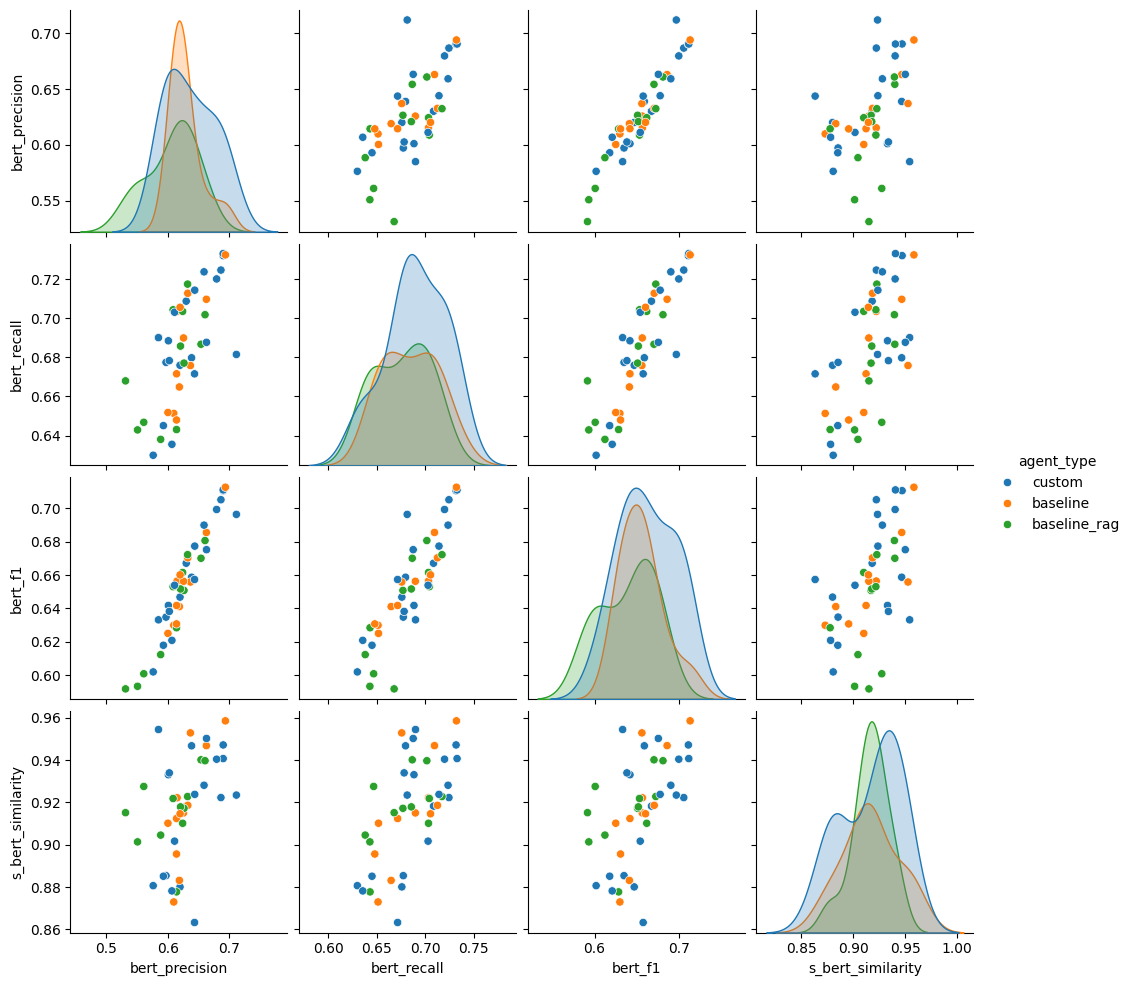

In [15]:
sns.pairplot(df[["bert_precision", "bert_recall", "bert_f1", "s_bert_similarity","llm_model", "agent_type"]], hue = "agent_type")

### Resource metrics
Token & time usage

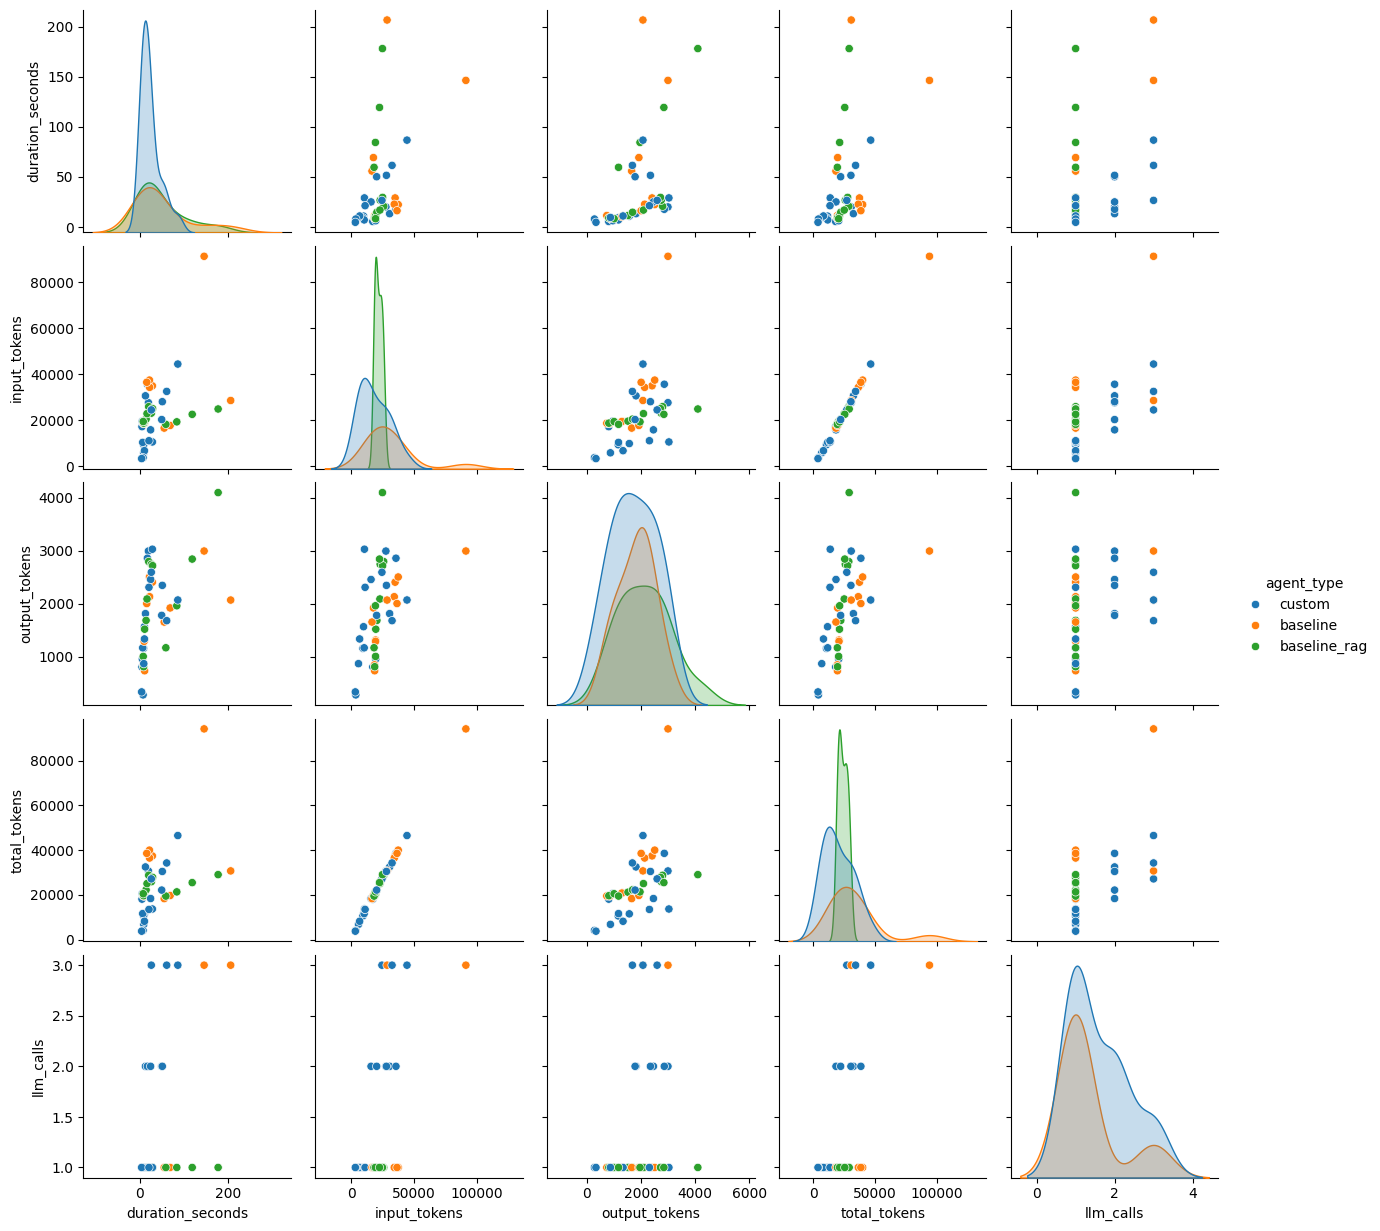

In [16]:
sns.pairplot(df[["duration_seconds", "input_tokens", "output_tokens", "total_tokens" , "llm_calls", "llm_model", "agent_type"]], hue = "agent_type")

### Combined analysis

In [17]:
df["llm_model"].value_counts()

llm_model
Qwen3-Next-80B-A3B-Instruct    24
Qwen3.5-397B-A17B              12
google_gemini-2.5-flash         8
Name: count, dtype: int64

<Axes: xlabel='duration_seconds', ylabel='correctness'>

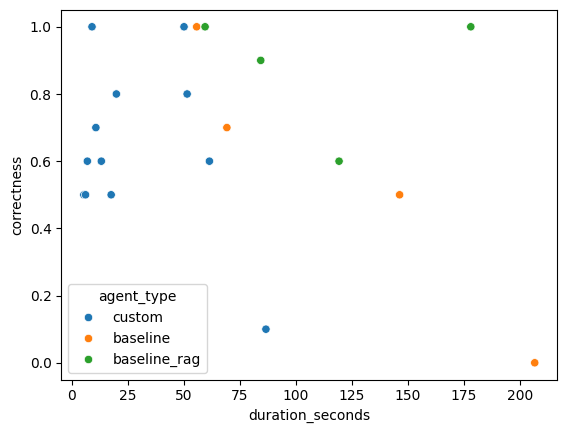

In [18]:
import seaborn as sns

sns.scatterplot(df.loc[df["llm_model"] != "Qwen3-Next-80B-A3B-Instruct", :], x = "duration_seconds", y = "correctness", hue = "agent_type")

In [19]:
dfg = df.groupby(by = ["agent_type", "llm_model"],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "total_tokens" : "mean"})

In [20]:
dfg

correctness  relevancy  \
agent_type   llm_model                                             
baseline     Qwen3-Next-80B-A3B-Instruct       0.6375     0.8375   
             Qwen3.5-397B-A17B                 0.5500     0.7000   
baseline_rag Qwen3-Next-80B-A3B-Instruct       0.5250     0.7375   
             Qwen3.5-397B-A17B                 0.8750     0.8750   
custom       Qwen3-Next-80B-A3B-Instruct       0.3250     0.3875   
             Qwen3.5-397B-A17B                 0.6250     0.6250   
             google_gemini-2.5-flash           0.6500     0.7625   

                                          completeness   bert_f1  \
agent_type   llm_model                                             
baseline     Qwen3-Next-80B-A3B-Instruct        0.7500  0.654582   
             Qwen3.5-397B-A17B                  0.6000  0.657062   
baseline_rag Qwen3-Next-80B-A3B-Instruct        0.6750  0.658495   
             Qwen3.5-397B-A17B                  0.8000  0.599463   
custom       Qwen3-Next-80B-A3B-Instruct        0.3375  0.659437   
             Qwen3.5-397B-A17B                  0.6250  0.665780   
             google_gemini-2.5-flash            0.6750  0.662199   

                                          duration_seconds  total_tokens  
agent_type   llm_model                                                    
baseline     Qwen3-Next-80B-A3B-Instruct         16.372052     29147.125  
             Qwen3.5-397B-A17B                  119.539563     40757.500  
baseline_rag Qwen3-Next-80B-A3B-Instruct         17.100490     23888.000  
             Qwen3.5-397B-A17B                  110.362954     23832.750  
custom       Qwen3-Next-80B-A3B-Instruct         16.800559     11935.000  
             Qwen3.5-397B-A17B                   62.452574     33362.500  
             google_gemini-2.5-flash             11.128313     21772.625

In [21]:
dfs = df.groupby(by = ["agent_type", "llm_model", "session",],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "total_tokens" : "mean"})

In [22]:
dfs

correctness  relevancy  \
agent_type   llm_model                   session                           
baseline     Qwen3-Next-80B-A3B-Instruct 0              0.500      0.825   
                                         1              0.775      0.850   
             Qwen3.5-397B-A17B           0              0.850      0.900   
                                         1              0.250      0.500   
baseline_rag Qwen3-Next-80B-A3B-Instruct 0              0.525      0.825   
                                         1              0.525      0.650   
             Qwen3.5-397B-A17B           0              0.950      0.950   
                                         1              0.800      0.800   
custom       Qwen3-Next-80B-A3B-Instruct 0              0.325      0.425   
                                         1              0.325      0.350   
             Qwen3.5-397B-A17B           0              0.900      0.750   
                                         1              0.350      0.500   
             google_gemini-2.5-flash     0              0.775      0.825   
                                         1              0.525      0.700   

                                                  completeness   bert_f1  \
agent_type   llm_model                   session                           
baseline     Qwen3-Next-80B-A3B-Instruct 0               0.625  0.649377   
                                         1               0.875  0.659787   
             Qwen3.5-397B-A17B           0               0.850  0.642499   
                                         1               0.350  0.671624   
baseline_rag Qwen3-Next-80B-A3B-Instruct 0               0.650  0.651057   
                                         1               0.700  0.665932   
             Qwen3.5-397B-A17B           0               0.800  0.601945   
                                         1               0.800  0.596981   
custom       Qwen3-Next-80B-A3B-Instruct 0               0.350  0.661387   
                                         1               0.325  0.657488   
             Qwen3.5-397B-A17B           0               0.850  0.676228   
                                         1               0.400  0.655332   
             google_gemini-2.5-flash     0               0.800  0.650123   
                                         1               0.550  0.674274   

                                                  duration_seconds  \
agent_type   llm_model                   session                     
baseline     Qwen3-Next-80B-A3B-Instruct 0               10.236283   
                                         1               22.507821   
             Qwen3.5-397B-A17B           0               62.518405   
                                         1              176.560721   
baseline_rag Qwen3-Next-80B-A3B-Instruct 0               10.806719   
                                         1               23.394261   
             Qwen3.5-397B-A17B           0               71.959495   
                                         1              148.766412   
custom       Qwen3-Next-80B-A3B-Instruct 0                8.198926   
                                         1               25.402192   
             Qwen3.5-397B-A17B           0               50.818562   
                                         1               74.086586   
             google_gemini-2.5-flash     0               11.673459   
                                         1               10.583167   

                                                  total_tokens  
agent_type   llm_model                   session                
baseline     Qwen3-Next-80B-A3B-Instruct 0            20168.00  
                                         1            38126.25  
             Qwen3.5-397B-A17B           0            19017.00  
                                         1            62498.00  
baseline_rag Qwen3-Next-80B-A3B-Instruct 0            20892.25  
                                        

## Statistical Modeling

In [20]:
import numpy as np
from scipy import stats 

from evals.models import DeepEvalObservation

In [21]:
class StatisticalMetrics:
    def __init__(self, significance_level: float = 0.05):
        self.significance_level = significance_level

    def check_normality(self, values : list[float]):
            result = stats.shapiro(values)
            status = "✅" if result.pvalue > self.significance_level else "❌"
            print(f"{status} : {result}")

    def t_test(self, custom_eval: list[float] | np.ndarray, comparison_eval: list[float] | np.ndarray):
        t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative='greater')
        print(f"Custom vs. Comparison: t={t_stat:.2f}, p={p:.4f}")
        if p < self.significance_level:
            print("Custom beats Comparison (p<0.05).")
        else:
            print("No significant difference (p>=0.05).")

def filter_evals(agent_type: str, metric: str = "correctness", llm_model: list[str] | None = None):
    if llm_model is not None:
        return df.loc[(df["agent_type"] == agent_type) & (df["llm_model"].isin(llm_model)), [metric]].values.flatten()  
    return df.loc[df["agent_type"] == agent_type, [metric]].values.flatten()

In [22]:
from collections import Counter
Counter(obs.agent_type for obs in deepeval_obs)

Counter({'custom': 20, 'baseline': 12, 'baseline_rag': 12})

### One-sided Hypothesis Tests

**For quality/performance metrics** (correctness, relevancy, completeness, passrate):

$$
H_0: \mu_{\text{custom}} \leq \mu_{\text{baseline}} \qquad H_1: \mu_{\text{custom}} > \mu_{\text{baseline}}
$$

(and analogously vs. baseline+RAG)

**For cost/efficiency metrics** (token usage, inference time):

$$
H_0: \mu_{\text{custom}} \geq \mu_{\text{baseline}} \qquad H_1: \mu_{\text{custom}} < \mu_{\text{baseline}}
$$

(and analogously vs. baseline+RAG)

**Notation:**

- $\mu_{\text{custom}}$ = population mean for the custom agent  
- $\mu_{\text{baseline}}$ = population mean for the baseline agent  
- $\mu_{\text{baseline+RAG}}$ = population mean for baseline with RAG  

All tests are one-tailed / one-sided.

In [23]:
filter_evals("custom", "correctness", ["google_gemini-2.5-flash"])

array([0.7, 0.8, 0.5, 0.6, 1. , 0.6, 0.5, 0.5])

In [24]:
sm = StatisticalMetrics()
sm.check_normality(filter_evals("custom", "correctness"))
sm.t_test(filter_evals("custom", "correctness", ["google_gemini-2.5-flash"]), filter_evals("baseline", "correctness", ["google_gemini-2.5-flash"]))

✅ : ShapiroResult(statistic=np.float64(0.9108847186674149), pvalue=np.float64(0.06625929583420709))
Custom vs. Comparison: t=nan, p=nan
No significant difference (p>=0.05).


/var/folders/qv/k9q4x60x4wn1fy68fsy_wtl00000gn/T/ipykernel_80698/3836300746.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative='greater')
